# Spider Silk Stretching

https://doi.org/10.1021/acs.biomac.7b00086

<img src="https://pubs.acs.org/cms/10.1021/acs.biomac.7b00086/asset/images/medium/bm-2017-00086f_0001.gif" width="300">

# Libraries & Set up

In [5]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


# Data

In [6]:
# SC5711 Data - Sergei Chvalun data

## Stretching
poni = r"E:\Silk_Chvalun\SC5711\Stretcher\Linkam_2DWAXS_13keV_300mm.poni"
ai = pyFAI.load(poni)

In [7]:
# Mask file 
mask = r"E:\Silk_Chvalun\SC5711\Stretcher\MASK_Stretcher.edf"
file_mask = mask
img_mask = fabio.open(mask).data

In [52]:
# 2D data
Exp0 = BM26_experiment(r'E:\Silk_Chvalun\SC5711\Stretcher\Stretcher_Sergei_silk_RT')
Exp0p5 = BM26_experiment(r'E:\Silk_Chvalun\SC5711\Stretcher\Stretcher_Sergei_silk_RT_0_50mm')
Exp_empty = BM26_experiment(r'E:\Silk_Chvalun\SC5711\Stretcher\Stretcher_Sergei_silk_RT_0_75mm')

# Functions

In [32]:
from pyFAI.gui import jupyter
from scipy.ndimage import gaussian_filter1d
def smooth_data(q, I, sigma=1.0, method='gaussian'):
    """
    Сглаживание данных для улучшения отображения на логарифмических осях
    
    Parameters:
    -----------
    q : array
        Вектор q-значений
    I : array
        Интенсивность
    sigma : float
        Параметр сглаживания
    method : str
        'gaussian' - гауссовский фильтр
        'savgol' - фильтр Савицкого-Голея
        'spline' - сплайн-интерполяция
    """
    if method == 'gaussian':
        # Гауссовское сглаживание
        I_smooth = gaussian_filter1d(I, sigma=sigma)
        return q, I_smooth
    
    elif method == 'savgol':
        # Фильтр Савицкого-Голея (нужен scipy)
        from scipy.signal import savgol_filter
        window_length = min(51, len(I) // 2 * 2 + 1)  # нечетное число
        I_smooth = savgol_filter(I, window_length, 3)
        return q, I_smooth
    
    elif method == 'spline':
        # Сплайн-интерполяция на логарифмической сетке
        log_q = np.log10(q)
        log_I = np.log10(I)
        
        # Создаем равномерную сетку в логарифмическом пространстве
        q_smooth = np.logspace(np.log10(q.min()), np.log10(q.max()), len(q)*2)
        log_q_smooth = np.log10(q_smooth)
        
        # Интерполируем
        spline = make_interp_spline(log_q, log_I, k=3)
        log_I_smooth = spline(log_q_smooth)
        
        return q_smooth, 10**log_I_smooth
    
    return q, I

# Analysis

### 1D integration

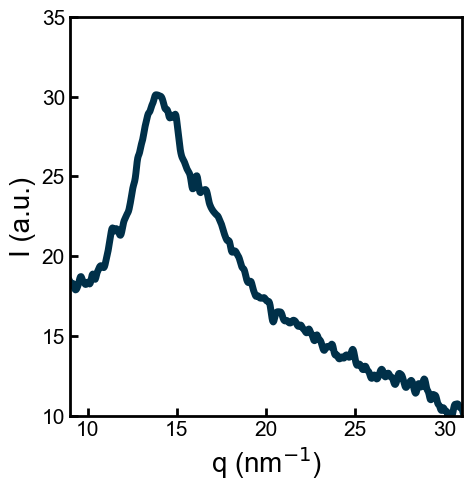

In [118]:
# Set global font to Arial and style for publication
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1,1, figsize=(5,5))

# Your data plotting
q, I_array1 = Exp0.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
#plt.plot(q, I_array1[0], color='#1982c4', label='0.0 mm', linewidth=2)

q, I_array2 = Exp_empty.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
#plt.plot(q, I_array2[0], color='#003049', label='empty', linewidth=2)

q, I = smooth_data(q, I_array1[0]-I_array2[0], sigma=2)
plt.plot(q, I, color='#003049', label='WAXS', linewidth=5)

# q, I = smooth_data(q, I_array1[0]-I_array2[0], sigma=3)
# plt.plot(q, I / 1.1, color='#003049', label='result', linewidth=2)

# q, I = smooth_data(q, I_array1[0]-I_array2[0], sigma=4)
# plt.plot(q, I / 1.1 / 1.1, color='#003049', label='result', linewidth=2)

# q, I = smooth_data(q, I_array1[0]-I_array2[0], sigma=5)
# plt.plot(q, I / 1.1 / 1.1 / 1.1, color='#003049', label='result', linewidth=2)

plt.xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)  # ← Markdown для степени
plt.ylabel('I (a.u.)', fontname='Arial', fontsize=20)

#plt.legend(frameon=False, fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.ylim(10, 35)
plt.xlim(9, 31)
plt.show()

probably only 1.5 and 2 mm samples were transmitted with a beam. 

In [16]:
Exp_empty.get_Tr_profile() # Transmission

[1.5256626691344453, 1.5249523987141667, 1.5251365662145238]

##### All experiments 

/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_25mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_5mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_75mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_25mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_50mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_75mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0_5mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bisbis_0_5mm
/Users

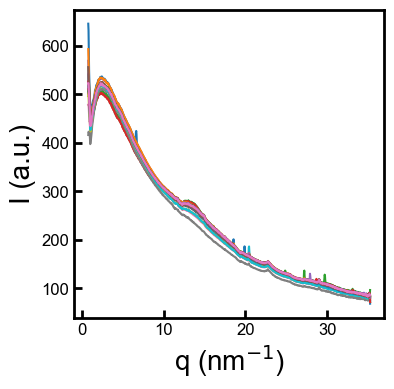

In [29]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

paths = list_experiments('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk') # all session

for path in paths:
    Exp = BM26_experiment(path)
    q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
    if max(I_array[0]) <= 1000:
        plt.plot(q, I_array[0])
        print(path)
    
    
plt.xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)  # ← Markdown для степени
plt.ylabel('I (a.u.)', fontname='Arial', fontsize=20)


plt.savefig('All_experiments_1D.png', dpi=300, bbox_inches='tight', transparent=True)

### 2D integration

##### 2mm

In [90]:
res0 = Exp0.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
res0p5 = Exp0p5.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
res_empty = Exp_empty.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
from scipy.ndimage import gaussian_filter
#jupyter.plot2d(res[0])

C:\Users\LabPC\AppData\Local\Temp\ipykernel_2276\509051544.py:27: RuntimeWarning: invalid value encountered in log10
  mesh = ax3.pcolormesh(res0[0][1], -res0[0][2], np.log10(res0[0][0] - 0.9*res_empty[0][0] +  1e-10), vmin=1.5, vmax=2., cmap='jet',rasterized=True)


(-5.0, 20.0)

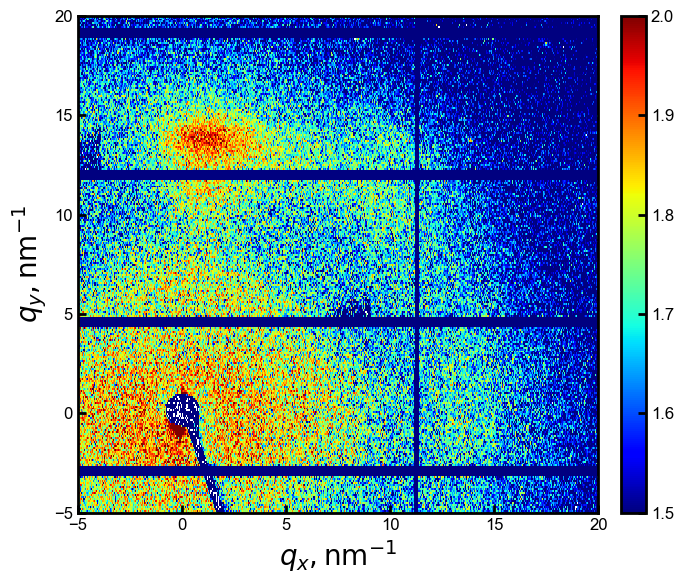

In [117]:
fig, ax3 = plt.subplots(1, 1, figsize=(7, 6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

# mesh = ax1.pcolormesh(res0[0][1], res0[0][2], np.log10(res0[0][0] +  1e-10), vmin=2, vmax=2.9, cmap='jet',rasterized=True)


# ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
# ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
# cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)
# #ax1.set_xlim(min(y), 0.9)
# #ax1.set_ylim(min(y), 0.9)


# mesh = ax2.pcolormesh(res_empty[0][1], res_empty[0][2], np.log10(res_empty[0][0] +  1e-10), vmin=2, vmax=2.9, cmap='jet',rasterized=True)


# ax2.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
# ax2.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
# cbar = fig.colorbar(mesh, ax=ax2, fraction=0.046, pad=0.04)

# mesh = ax3.pcolormesh(res0[0][1], res0[0][2], gaussian_filter(np.log10(res0[0][0] - 0.96*res_empty[0][0] +  1e-10), sigma=1), vmin=1.5, vmax=2, cmap='jet',rasterized=True)
mesh = ax3.pcolormesh(res0[0][1], -res0[0][2], np.log10(res0[0][0] - 0.9*res_empty[0][0] +  1e-10), vmin=1.5, vmax=2., cmap='jet',rasterized=True)


ax3.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax3.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
cbar = fig.colorbar(mesh, ax=ax3, fraction=0.046, pad=0.04)
ax3.set_xlim(-5, 20)
ax3.set_ylim(-5, 20)


##### 0.5 back

In [25]:
res = Exp0p5_back.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
#jupyter.plot2d(res[0])

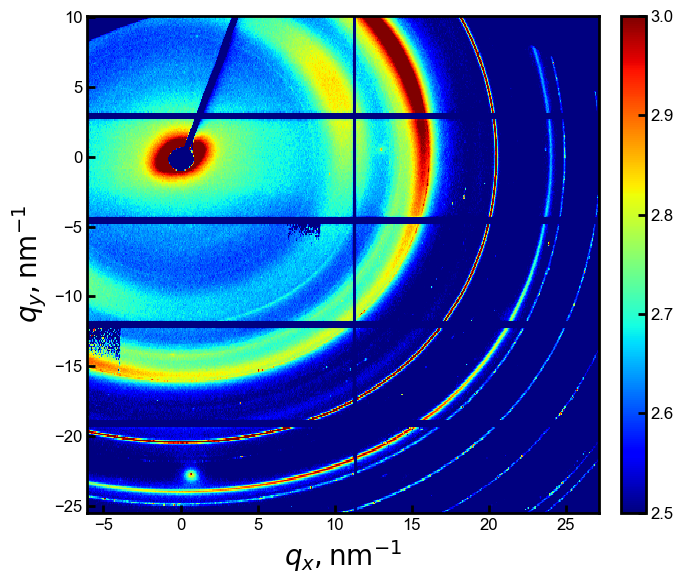

In [26]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2.5, vmax=3., cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
#ax1.set_xlim(min(y), 0.9)
#ax1.set_ylim(min(y), 0.9)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

plt.savefig('Silk_bis_0p5mm_2D_plot.png', dpi=300, bbox_inches='tight', transparent=True)

#### Another experiment

In [55]:
Exp = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_secondsample_0_25mm')

res = Exp.integrate2d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1', azim=False)

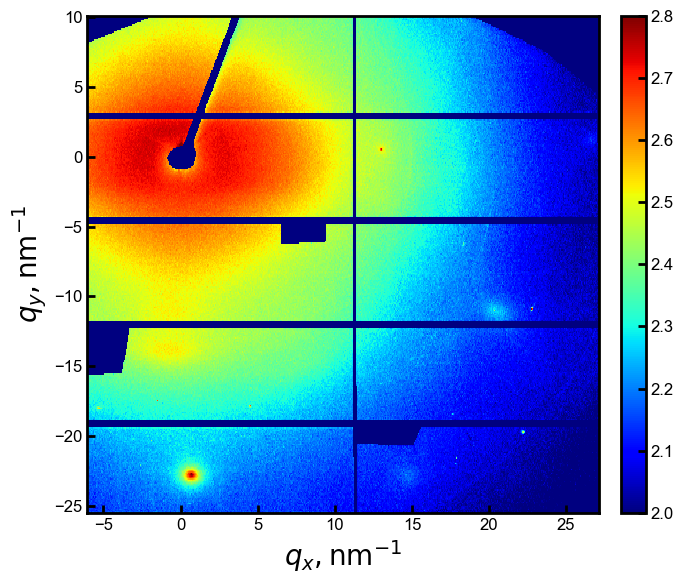

In [60]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2., vmax=2.8, cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
#ax1.set_xlim(min(y), 0.9)
#ax1.set_ylim(min(y), 0.9)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

plt.savefig('Silk_RT.png', dpi=300, bbox_inches='tight', transparent=True)